In [11]:

# Import libraries
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Load dataset
df = pd.read_csv('Groceries_dataset.csv')

# Display first rows
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [13]:
# Group items by Transaction
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

# Show sample transactions
transactions[:5]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables']]

In [14]:
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_data, columns=te.columns_)

df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:

# LOWER support
frequent_itemsets = apriori(df_encoded, min_support=0.005, use_colnames=True)


frequent_itemsets.head()

,support,itemsets
0,0.021386,(UHT-milk)
1,0.008087,(baking powder)
2,0.033950,(beef)
3,0.021787,(berries)
4,0.016574,(beverages)


In [16]:
# LOWER confidence
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
1,(bottled water),(whole milk),0.060683,0.157923,0.007151,0.117841,0.746196,1.0,-0.002432,0.954564,-0.265842,0.033818,-0.047598,0.081561
2,(canned beer),(whole milk),0.046916,0.157923,0.006015,0.128205,0.811821,1.0,-0.001394,0.965912,-0.195630,0.030252,-0.035291,0.083146
3,(citrus fruit),(whole milk),0.053131,0.157923,0.007151,0.134591,0.852259,1.0,-0.001240,0.973040,-0.154748,0.035070,-0.027707,0.089936
4,(domestic eggs),(whole milk),0.037091,0.157923,0.005280,0.142342,0.901341,1.0,-0.000578,0.981834,-0.102072,0.027827,-0.018503,0.087887


In [17]:
strong_rules = rules[rules['lift'] > 1]

strong_rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5,(frankfurter),(other vegetables),0.03776,0.122101,0.005146,0.136283,1.11615,1.0,0.000536,1.01642,0.108146,0.033261,0.016154,0.089214


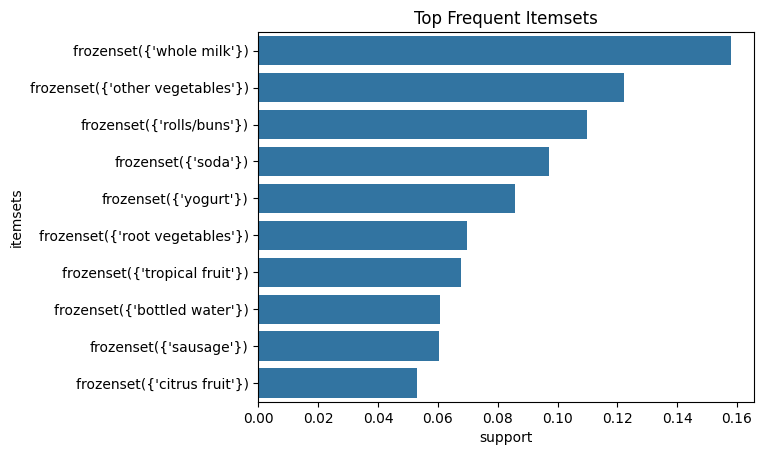

In [18]:
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.figure()
sns.barplot(x=top_items['support'], y=top_items['itemsets'])
plt.title("Top Frequent Itemsets")
plt.show()

In [19]:
print("Frequent Itemsets:", frequent_itemsets.shape)
print("Rules:", rules.shape)

Frequent Itemsets: (126, 2)
Rules: (19, 14)


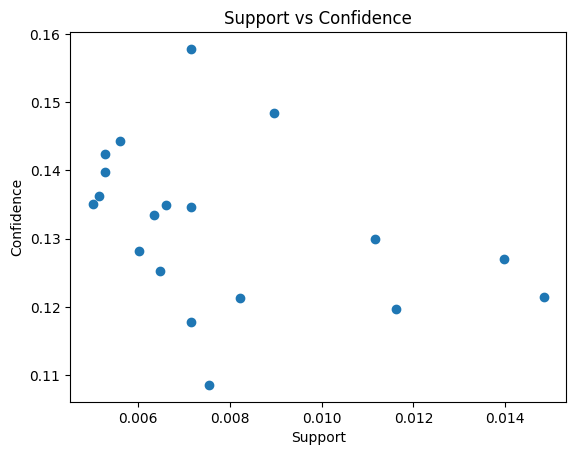

In [20]:
if not rules.empty:
    plt.figure()
    plt.scatter(rules['support'], rules['confidence'])
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.title("Support vs Confidence")
    plt.show()
else:
    print("No rules generated. Reduce support/confidence.")